# Feature Engineering

Create model-ready features for training and evaluation in a reproducible, production-ready flow.

In [12]:
import pandas as pd
import numpy as np
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Libraries imported successfully.")

Libraries imported successfully.


In [13]:
required_source_columns = [
    "Name",
    "Dimensions",
    "SoC",
    "CPU",
    "GPU",
    "RAM",
    "Storage",
    "Display",
    "Battery",
    "OS",
    "Camera",
    "Launch_Year",
    "Series",
    "Main_Camera_MP",
    "UltraWide_MP",
    "Telephoto_MP",
    "Front_Camera_MP",
    "OIS",
    "AI_Features",
    "Waterproof",
    "Target_Segment",
]

data_path = "../data/processed/cleaned_dataset.csv"
df = pd.read_csv(data_path)

missing_source_columns = [column for column in required_source_columns if column not in df.columns]

print(f"Loaded dataset shape: {df.shape}")
print(f"Available columns: {df.columns.tolist()}")

if missing_source_columns:
    print(f"WARNING: Missing expected source columns: {missing_source_columns}")
else:
    print("All expected source columns are present.")

df.head()

Loaded dataset shape: (749, 21)
Available columns: ['Name', 'Dimensions', 'SoC', 'CPU', 'GPU', 'RAM', 'Storage', 'Display', 'Battery', 'OS', 'Camera', 'Launch_Year', 'Series', 'Main_Camera_MP', 'UltraWide_MP', 'Telephoto_MP', 'Front_Camera_MP', 'OIS', 'AI_Features', 'Waterproof', 'Target_Segment']
All expected source columns are present.


,Name,Dimensions,SoC,CPU,GPU,RAM,Storage,Display,Battery,OS,Camera,Launch_Year,Series,Main_Camera_MP,UltraWide_MP,Telephoto_MP,Front_Camera_MP,OIS,AI_Features,Waterproof,Target_Segment
0,Ativ Odyssey,59 x 110.1 x 12.3 mm,Samsung Exynos 4 Quad 4412,"2x 1.5 GHz Krait,",Broadcom VideoCore IV,"1 GB, 400 MHz",8 GB,"4 in, Super AMOLED, 480 x 800 pixels, 24 bit","2100 mAh, Li-Ion",Android 4.1.2 Jelly Bean,"3264 x 2448 pixels, 1920 x 1080 pixels, 30 fps",NaN,Other,8,0.0,0.0,NaN,No,No,No,Budget
1,Ativ S,63.1 x 121.5 x 10.5 mm,Qualcomm Snapdragon S1 (MSM7225A),"2x 1.5 GHz Krait,","Qualcomm Adreno 225, 400 MHz","768 MB, 333 MHz",4 GB,"4.8 in, Super AMOLED, 720 x 1280 pixels, 24 bit","2300 mAh, Li-Ion",Android 4.0.4 Ice Cream Sandwich,"2048 x 1536 pixels, 1920 x 1080 pixels, 30 fps",NaN,Other,3,0.0,0.0,NaN,No,No,No,Budget
2,ATIV S Neo,61.3 x 124.6 x 8.94 mm,Qualcomm Snapdragon S2 (MSM8655),"2x 1.4 GHz Krait 300,",ARM Mali-400 MP4,"1.5 GB, 400 MHz",8 GB,"4.77 in, TFT, 720 x 1280 pixels, 24 bit","2000 mAh, Li-Ion",Android 4.2.2 Jelly Bean,"3264 x 2448 pixels, 1920 x 1080 pixels, 30 fps",NaN,Other,8,0.0,0.0,NaN,No,No,No,Budget
3,Ativ SE,186.9 x 107.9 x 9 mm,Qualcomm Snapdragon 400 (MSM8226),"4x 2.26 GHz Krait 400,","Qualcomm Adreno 305, 450 MHz","2 GB, 800 MHz",16 GB,"5 in, AMOLED, 1080 x 1920 pixels, 24 bit","2600 mAh, Li-Ion",Microsoft Windows Phone 8,"2048 x 1536 pixels, 1280 x 720 pixels, 30 fps",NaN,Other,3,0.0,0.0,NaN,No,No,No,Budget
4,Ativ Tab,63.5 x 121.9 x 12.7 mm,Qualcomm Snapdragon S4 Plus (MSM8960),"2x 1.5 GHz Krait,","Qualcomm Adreno 200, 245 MHz",1 GB,"8 GB, 16 GB","10.1 in, PLS, 1366 x 768 pixels, 24 bit","8200 mAh, Li-Ion",Android 4.0 Ice Cream Sandwich,"3264 x 2448 pixels, 1920 x 1080 pixels, 30 fps",NaN,Galaxy Tab Series,8,0.0,0.0,NaN,No,No,No,Budget


In [14]:
def print_warning(message):
    print(f"WARNING: {message}")

def extract_ram_gb(value):
    if pd.isna(value):
        return np.nan

    text = str(value)
    matches = re.findall(r'(\d+(?:\.\d+)?)\s*(TB|GB|MB)', text, flags=re.IGNORECASE)

    if not matches:
        return np.nan

    converted_values = []
    for number, unit in matches:
        numeric_value = float(number)
        unit = unit.upper()

        if unit == "TB":
            numeric_value *= 1024
        elif unit == "MB":
            numeric_value /= 1024

        converted_values.append(numeric_value)

    return max(converted_values)

def extract_storage_gb(value):
    if pd.isna(value):
        return np.nan

    text = str(value)
    matches = re.findall(r'(\d+(?:\.\d+)?)\s*(TB|GB|MB)', text, flags=re.IGNORECASE)

    if not matches:
        return np.nan

    converted_values = []
    for number, unit in matches:
        numeric_value = float(number)
        unit = unit.upper()

        if unit == "TB":
            numeric_value *= 1024
        elif unit == "MB":
            numeric_value /= 1024

        converted_values.append(numeric_value)

    return max(converted_values)

def extract_battery_mAh(value):
    if pd.isna(value):
        return np.nan

    text = str(value)
    match = re.search(r'(\d+(?:\.\d+)?)\s*mAh', text, flags=re.IGNORECASE)

    if match:
        return float(match.group(1))

    return np.nan

def extract_screen_size_inch(value):
    if pd.isna(value):
        return np.nan

    text = str(value)

    patterns = [
        r'(\d+(?:\.\d+)?)\s*(?:-|\s)?(?:inch|inches|in|\")',
        r'(\d+(?:\.\d+)?)\s*(?:-|\s)?(?:\u201d|\u201c)',
    ]

    for pattern in patterns:
        match = re.search(pattern, text, flags=re.IGNORECASE)
        if match:
            return float(match.group(1))

    return np.nan

def extract_refresh_rate_hz(value):
    if pd.isna(value):
        return 60.0

    text = str(value)
    match = re.search(r'(\d+)\s*Hz', text, flags=re.IGNORECASE)

    if match:
        return float(match.group(1))

    return 60.0

In [23]:
df["RAM_GB"] = df["RAM"].apply(extract_ram_gb)
df["Storage_GB"] = df["Storage"].apply(extract_storage_gb)
df["Battery_mAh"] = df["Battery"].apply(extract_battery_mAh)
df["Screen_Size_Inch"] = df["Display"].apply(extract_screen_size_inch)
df["Refresh_Rate_Hz"] = df["Display"].apply(extract_refresh_rate_hz)

# Safe imputation for rows where extraction fails
df["RAM_GB"] = df["RAM_GB"].fillna(df["RAM_GB"].median())
df["Storage_GB"] = df["Storage_GB"].fillna(df["Storage_GB"].median())
df["Battery_mAh"] = df["Battery_mAh"].fillna(df["Battery_mAh"].median())
df["Screen_Size_Inch"] = df["Screen_Size_Inch"].fillna(df["Screen_Size_Inch"].median())
df["Refresh_Rate_Hz"] = df["Refresh_Rate_Hz"].fillna(60.0)

extracted_columns = [
    "RAM",
    "RAM_GB",
    "Storage",
    "Storage_GB",
    "Battery",
    "Battery_mAh",
    "Display",
    "Screen_Size_Inch",
    "Refresh_Rate_Hz",
]

print(df[extracted_columns].head(10))

                RAM  RAM_GB              Storage  Storage_GB            Battery  Battery_mAh                                           Display  Screen_Size_Inch  Refresh_Rate_Hz
0     1 GB, 400 MHz   1.000                 8 GB       8.000   2100 mAh, Li-Ion       2100.0      4 in, Super AMOLED, 480 x 800 pixels, 24 bit              4.00             60.0
1   768 MB, 333 MHz   0.750                 4 GB       4.000   2300 mAh, Li-Ion       2300.0   4.8 in, Super AMOLED, 720 x 1280 pixels, 24 bit              4.80             60.0
2   1.5 GB, 400 MHz   1.500                 8 GB       8.000   2000 mAh, Li-Ion       2000.0           4.77 in, TFT, 720 x 1280 pixels, 24 bit              4.77             60.0
3     2 GB, 800 MHz   2.000                16 GB      16.000   2600 mAh, Li-Ion       2600.0          5 in, AMOLED, 1080 x 1920 pixels, 24 bit              5.00             60.0
4              1 GB   1.000          8 GB, 16 GB      16.000   8200 mAh, Li-Ion       8200.0           10.1 in

In [16]:
def normalize(series):
    numeric_series = pd.to_numeric(series, errors="coerce")
    normalized_series = pd.Series(5.0, index=series.index, dtype=float)

    valid_values = numeric_series.dropna()
    if valid_values.empty:
        return normalized_series

    minimum_value = valid_values.min()
    maximum_value = valid_values.max()

    if minimum_value == maximum_value:
        return normalized_series

    normalized_values = 10 * (numeric_series - minimum_value) / (maximum_value - minimum_value)
    normalized_values = normalized_values.clip(0, 10)
    normalized_values = normalized_values.fillna(5.0)

    return normalized_values.astype(float)

def encode_ois_flag(value):
    if pd.isna(value):
        return 0

    text = str(value).strip().lower()
    return int(text in {"yes", "true", "1", "y", "ois"})

In [24]:
df["camera_score"] = (
    0.60 * normalize(df["Main_Camera_MP"]) +
    0.20 * normalize(df["UltraWide_MP"]) +
    0.15 * normalize(df["Telephoto_MP"]) +
    0.05 * (df["OIS"].apply(encode_ois_flag) * 10)
 )

df["performance_score"] = (
    0.70 * normalize(df["RAM_GB"]) +
    0.30 * normalize(df["Storage_GB"])
 )

print(df[["camera_score", "performance_score"]].head(10))

   camera_score  performance_score
0          0.24           0.409208
1          0.09           0.287252
2          0.24           0.629680
3          0.09           0.873590
4          0.24           0.432646
5          0.24           0.259049
6          0.15           0.133617
7          0.09           0.165754
8          0.06           0.432646
9          0.24           0.322409


In [25]:
df["battery_score"] = normalize(df["Battery_mAh"])

df["display_score"] = (
    0.50 * normalize(df["Screen_Size_Inch"]) +
    0.50 * normalize(df["Refresh_Rate_Hz"])
 )

print(df[["battery_score", "display_score"]].head(10))

   battery_score  display_score
0       1.603053       3.214286
1       1.772689       3.452381
2       1.518236       3.443452
3       2.027142       3.511905
4       6.776930       5.029762
5       0.670059       2.738095
6       1.221374       3.214286
7       0.670059       2.857143
8       0.670059       2.738095
9       0.500424       2.619048


In [26]:
def encode_ai_score(value):
    if pd.isna(value):
        return 0.0

    text = str(value).strip().lower()

    if "galaxy ai" in text:
        return 10.0

    if "basic ai" in text:
        return 5.0

    if text in {"no", "none", "no ai", "0", "", "na", "n/a"}:
        return 0.0

    return 0.0

df["ai_score"] = df["AI_Features"].apply(encode_ai_score)
df["durability_score"] = df["Waterproof"].apply(
    lambda value: 10.0 if str(value).strip().lower() in {"yes", "true", "1", "y"} else 0.0
)

print(df[["ai_score", "durability_score"]].head(10))

   ai_score  durability_score
0       0.0               0.0
1       0.0               0.0
2       0.0               0.0
3       0.0               0.0
4       0.0               0.0
5       0.0               0.0
6       0.0               0.0
7       0.0               0.0
8       0.0               0.0
9       0.0               0.0


In [31]:
# 11) Recommendation score (formula unchanged) and post-normalization to 0-10
recommendation_score_raw = (
    0.30 * df["performance_score"] +
    0.25 * df["camera_score"] +
    0.15 * df["battery_score"] +
    0.15 * df["display_score"] +
    0.10 * df["ai_score"] +
    0.05 * df["durability_score"]
)

# Normalize only the final recommendation score
df["recommendation_score"] = normalize(recommendation_score_raw)

print(df[["recommendation_score"]].head(10))

   recommendation_score
0              0.561184
1              0.543308
2              0.682593
3              0.851687
4              2.020724
5              0.206578
6              0.336564
7              0.140710
8              0.216368
9              0.172982


In [32]:
# 12) Validation setup
engineered_feature_columns = [
    "RAM_GB",
    "Storage_GB",
    "Battery_mAh",
    "Screen_Size_Inch",
    "Refresh_Rate_Hz",
    "camera_score",
    "performance_score",
    "battery_score",
    "display_score",
    "ai_score",
    "durability_score",
    "recommendation_score",
]

score_columns = [
    "camera_score",
    "performance_score",
    "battery_score",
    "display_score",
    "ai_score",
    "durability_score",
    "recommendation_score",
]

top_bottom_columns = [
    "Name",
    "Series",
    "recommendation_score",
    "camera_score",
    "performance_score",
    "battery_score",
    "display_score",
    "ai_score",
    "durability_score",
]

def validate_engineered_features(frame, engineered_columns, score_cols):
    report = {}

    # Structural checks
    missing_columns = [column for column in engineered_columns if column not in frame.columns]
    duplicate_columns_exist = frame.columns.duplicated().any()

    # Dataset-level checks
    engineered_frame = frame[engineered_columns].copy()
    missing_values_exist = engineered_frame.isna().any().any()
    infinite_values_exist = np.isinf(engineered_frame.select_dtypes(include=[np.number]).to_numpy()).any()

    # Type checks
    non_numeric_columns = [
        column
        for column in engineered_columns
        if not pd.api.types.is_numeric_dtype(frame[column])
    ]

    # Per-score range checks
    score_range_results = {}
    for column in score_cols:
        column_min = frame[column].min()
        column_max = frame[column].max()
        score_range_results[column] = bool((column_min >= 0) and (column_max <= 10))

    # Compose pass/fail report
    report["missing_values"] = not missing_values_exist
    report["infinite_values"] = not infinite_values_exist
    report["duplicate_columns"] = not duplicate_columns_exist
    report["numeric_data_types"] = len(non_numeric_columns) == 0
    report["score_ranges"] = all(score_range_results.values())

    print("=" * 33)
    print("FEATURE VALIDATION REPORT")
    print("=" * 33)

    for column in score_cols:
        status = "PASS" if score_range_results[column] else "FAIL"
        print(f"{column:.<24} {status}")

    print("-" * 33)
    print(f"missing_values.......... {'PASS' if report['missing_values'] else 'FAIL'}")
    print(f"infinite_values......... {'PASS' if report['infinite_values'] else 'FAIL'}")
    print(f"duplicate_columns....... {'PASS' if report['duplicate_columns'] else 'FAIL'}")
    print(f"numeric_data_types...... {'PASS' if report['numeric_data_types'] else 'FAIL'}")
    print(f"score_ranges............ {'PASS' if report['score_ranges'] else 'FAIL'}")
    print("=" * 33)

    if missing_columns:
        print_warning(f"Missing engineered columns: {missing_columns}")
    if non_numeric_columns:
        print_warning(f"Non-numeric engineered columns: {non_numeric_columns}")

    return report

In [33]:
# 13) Validation report + statistical summary + top/bottom recommendations
validation_report = validate_engineered_features(df, engineered_feature_columns, score_columns)

print("\nStatistical summary (engineered features):")
print(df[engineered_feature_columns].describe().T)

print("\nTop 20 Recommendations:")
top_20 = df.sort_values(by="recommendation_score", ascending=False)[top_bottom_columns].head(20)
print(top_20.to_string(index=False))

print("\nBottom 20 Recommendations:")
bottom_20 = df.sort_values(by="recommendation_score", ascending=True)[top_bottom_columns].head(20)
print(bottom_20.to_string(index=False))

FEATURE VALIDATION REPORT
camera_score............ PASS
performance_score....... PASS
battery_score........... PASS
display_score........... PASS
ai_score................ PASS
durability_score........ PASS
recommendation_score.... PASS
---------------------------------
missing_values.......... PASS
infinite_values......... PASS
duplicate_columns....... PASS
numeric_data_types...... PASS
score_ranges............ PASS

Statistical summary (engineered features):
                      count         mean          std         min          25%          50%          75%      max
RAM_GB                749.0     4.098053     3.531066    0.125000     1.500000     3.000000     6.000000     16.0
Storage_GB            749.0   110.909005   169.964472    0.019500    16.000000    32.000000   128.000000   1024.0
Battery_mAh           749.0  3908.831776  1997.362818  210.000000  2600.000000  3500.000000  5000.000000  12000.0
Screen_Size_Inch      749.0     6.292029     2.243789    1.600000     5.000000  

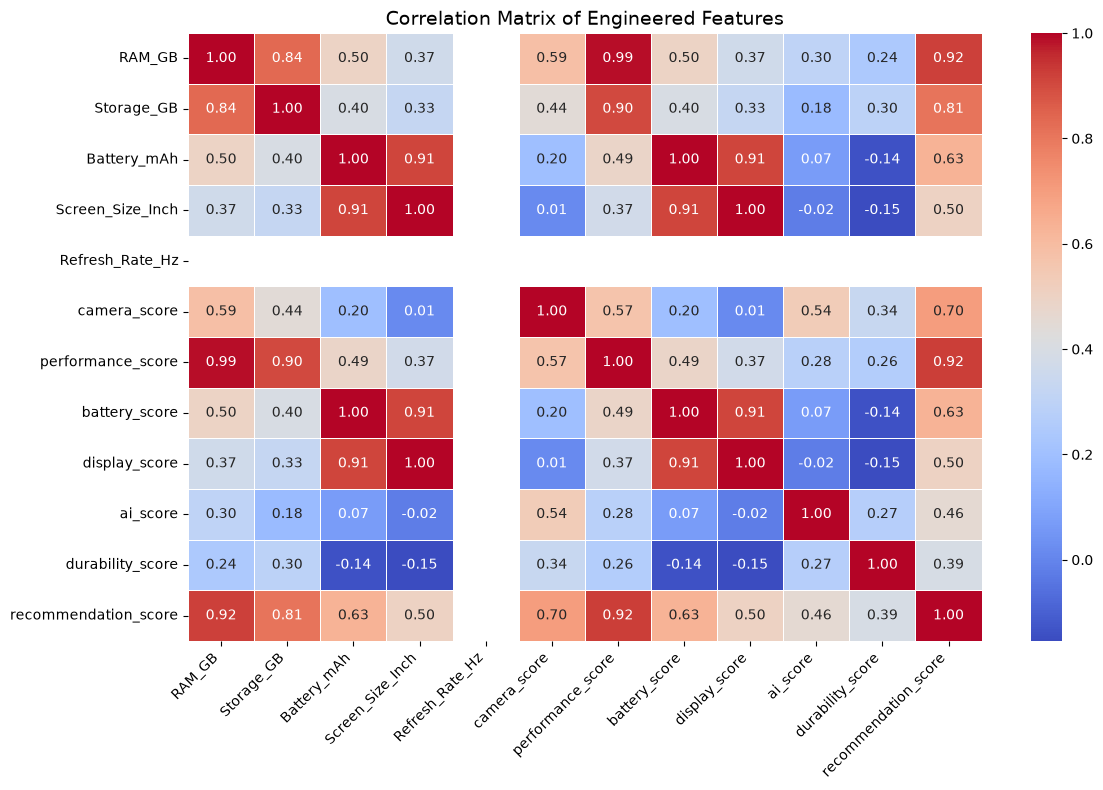

In [34]:
# 14) Correlation analysis heatmap (engineered numerical features)
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df[engineered_feature_columns].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar=True,
    square=False
)
plt.title("Correlation Matrix of Engineered Features", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

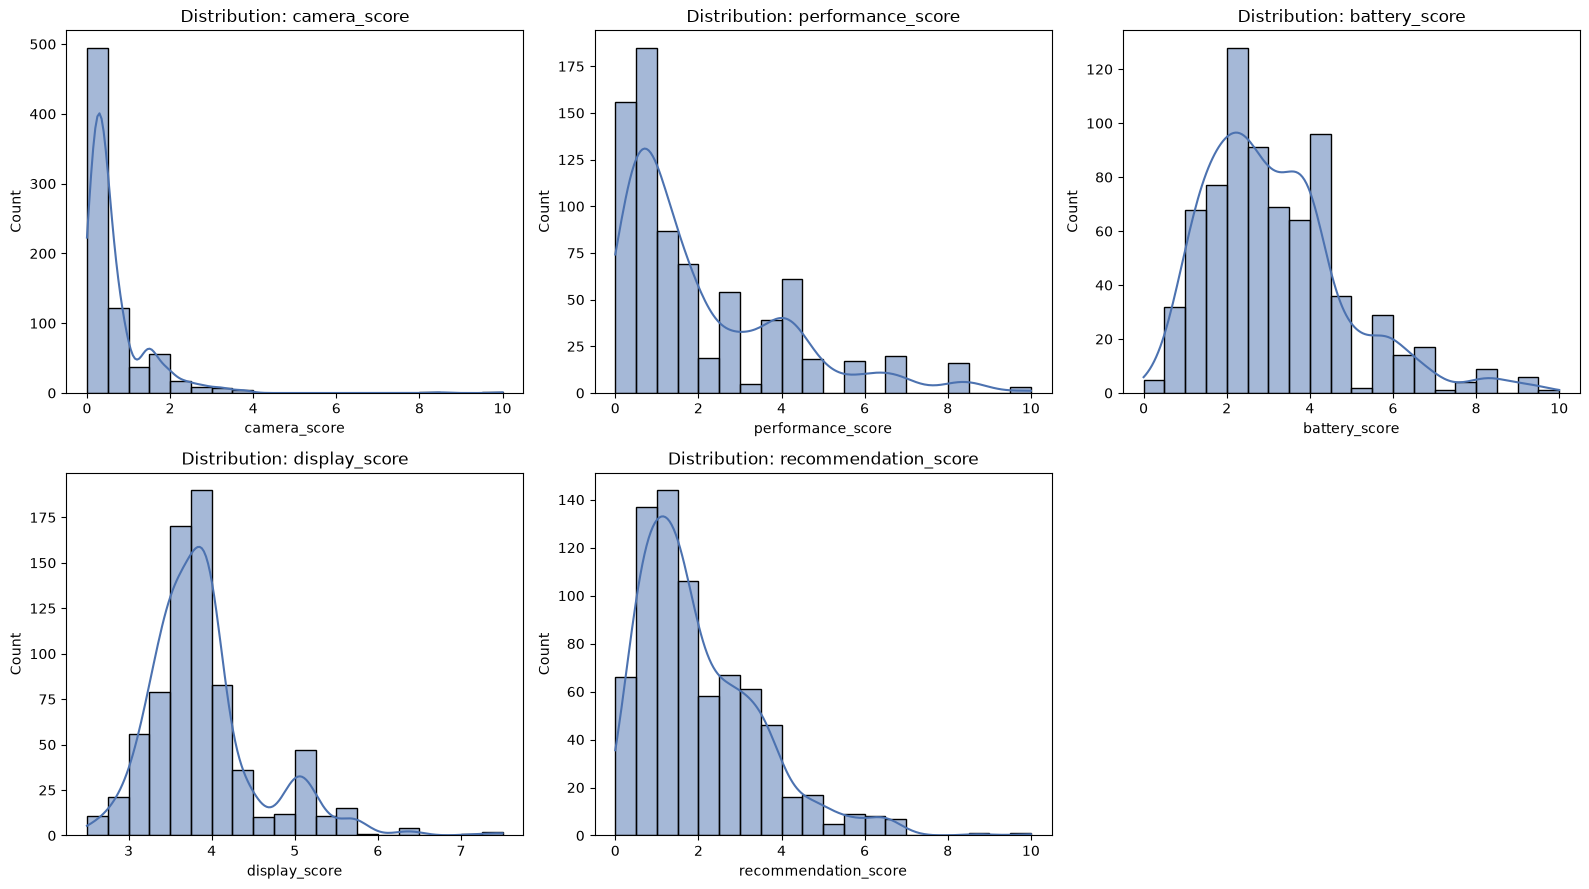

In [35]:
# 15) Distribution plots for key scores
distribution_columns = [
    "camera_score",
    "performance_score",
    "battery_score",
    "display_score",
    "recommendation_score",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for index, column in enumerate(distribution_columns):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=20,
        ax=axes[index],
        color="#4C72B0"
    )
    axes[index].set_title(f"Distribution: {column}")
    axes[index].set_xlabel(column)
    axes[index].set_ylabel("Count")

# Hide the unused 6th subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [36]:
# 16) Save final engineered dataset
output_path = "../data/processed/engineered_dataset.csv"
df.to_csv(output_path, index=False)
print(f"Engineered dataset saved to: {output_path}")

Engineered dataset saved to: ../data/processed/engineered_dataset.csv
